# Практическая работа №5: Элементы регрессионного анализа. Выборочные прямые среднеквадратической регрессии. Корреляционные отношения

Выполнили студенты гр. 2384 Тимченко Дмитрий и Цыганков Роман.

## Цель работы

Ознакомление с основными положениями метода наименьших квадратов (МНК), со статистическими свойствами МНК-оценок, с понятием функции регрессии и ролью МНК в регрессионном анализе, с корреляционным отношением как мерой тесноты произвольной корреляционной связи.

## Основные теоретические положения

**Прямая регрессии Y на X** (МНК-оценка):
$$\hat{y} = \bar{y} + r\frac{\sigma_y}{\sigma_x}(x - \bar{x})$$

**Прямая регрессии X на Y:**
$$\hat{x} = \bar{x} + r\frac{\sigma_x}{\sigma_y}(y - \bar{y})$$

Обе прямые пересекаются в точке $(\bar{x}, \bar{y})$.

**Корреляционное отношение** — мера тесноты произвольной (не только линейной) связи:
$$\eta^2_{y|x} = \frac{D(\bar{y}_i)}{D_y} = \frac{\frac{1}{n}\sum_i n_i(\bar{y}_i - \bar{y})^2}{D_y}$$
где $\bar{y}_i$ — условное среднее Y в $i$-м интервале X.

Всегда выполняется: $\eta_{y|x} \geq |r_{xy}|$, $\eta_{x|y} \geq |r_{xy}|$.

При линейной зависимости $\eta = |r|$.

**Показатели качества регрессии:**
$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}, \quad S_{\varepsilon} = \sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}, \quad A = \frac{1}{n}\sum\left|\frac{y_i - \hat{y}_i}{y_i}\right| \cdot 100\%$$

## Постановка задачи

Исследуется двумерная выборка $n = 108$: **X = nu** (объёмный вес, г/см³) и **Y = E** (модуль упругости, кг/см²) резонансной ели. Используются результаты ПР №4.

Вариант кривой регрессии (п.5): **4 — логарифмическая** $y = \beta_0 + \beta_1 \ln x$.

## Загрузка данных

In [2]:
import pandas as pd
import numpy as np
from scipy import stats, optimize
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

df = pd.read_csv('sample.csv', skiprows=3)
sample_2d = df[['nu', 'E']].head(108)
x = sample_2d['nu'].values  # X = nu
y = sample_2d['E'].values   # Y = E
n = 108; k = 8

x_bar = np.mean(x); y_bar = np.mean(y)
sigma_x = np.std(x, ddof=0); sigma_y = np.std(y, ddof=0)
r = np.corrcoef(x, y)[0, 1]
ss_tot = np.sum((y - y_bar)**2)

print(f'n = {n}')
print(f'x_bar = {x_bar:.4f}, sigma_x = {sigma_x:.4f}')
print(f'y_bar = {y_bar:.4f}, sigma_y = {sigma_y:.4f}')
print(f'r = {r:.6f}')
print(f'SS_tot = {ss_tot:.4f}')

n = 108
x_bar = 449.9167, sigma_x = 59.9233
y_bar = 127.4306, sigma_y = 24.7637
r = 0.925157
SS_tot = 66230.0492


## 1. Диаграмма рассеяния двумерной выборки

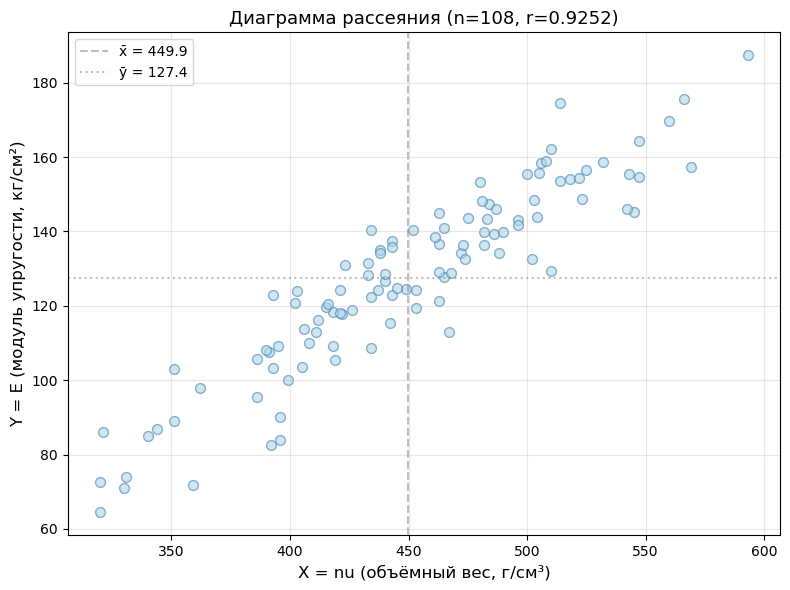

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y, alpha=0.6, edgecolors='steelblue', facecolors='lightblue', s=50)
ax.axvline(x_bar, color='gray', linestyle='--', alpha=0.5, label=f'x̄ = {x_bar:.1f}')
ax.axhline(y_bar, color='gray', linestyle=':',  alpha=0.5, label=f'ȳ = {y_bar:.1f}')
ax.set_xlabel('X = nu (объёмный вес, г/см³)', fontsize=12)
ax.set_ylabel('Y = E (модуль упругости, кг/см²)', fontsize=12)
ax.set_title(f'Диаграмма рассеяния (n={n}, r={r:.4f})', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scatter_raw.png', dpi=120, bbox_inches='tight')
plt.show()

**Вывод:** Диаграмма рассеяния демонстрирует выраженную положительную линейную тенденцию — точки вытянуты вдоль прямой с возрастающим наклоном. Разброс относительно тренда умеренный и равномерный. Это подтверждает высокое значение $r = 0.9252$, полученное в ПР №4, и указывает на то, что линейная модель регрессии должна хорошо описывать данную зависимость.

## 2. Прямые среднеквадратической регрессии

МНК-оценки коэффициентов:

**Y на X:** $\hat{y} = \bar{y} + r \dfrac{\sigma_y}{\sigma_x}(x - \bar{x}) = b_0 + b_1 x$

**X на Y:** $\hat{x} = \bar{x} + r \dfrac{\sigma_x}{\sigma_y}(y - \bar{y}) = a_0 + a_1 y$

ПРЯМЫЕ РЕГРЕССИИ:
  Y на X: ŷ = -44.5851 + 0.3823 * x
  X на Y: x̂ = 164.6381 + 2.2387 * y

Точка пересечения: (449.9167, 127.4306)
Проверка Y→X в точке x̄: ŷ = 127.4306 (должно быть 127.4306)
Проверка X→Y в точке ȳ: x̂ = 449.9167 (должно быть 449.9167)


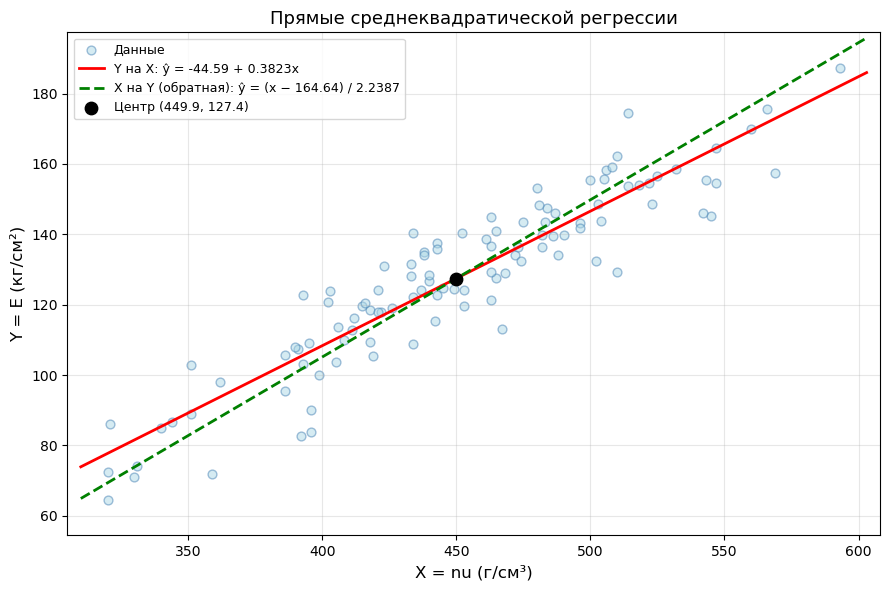

In [33]:
# Regression Y on X
b1_yx = r * sigma_y / sigma_x
b0_yx = y_bar - b1_yx * x_bar

# Regression X on Y
b1_xy = r * sigma_x / sigma_y
b0_xy = x_bar - b1_xy * y_bar

print('ПРЯМЫЕ РЕГРЕССИИ:')
print(f'  Y на X: ŷ = {b0_yx:.4f} + {b1_yx:.4f} * x')
print(f'  X на Y: x̂ = {b0_xy:.4f} + {b1_xy:.4f} * y')
print()
print(f'Точка пересечения: ({x_bar:.4f}, {y_bar:.4f})')
print(f'Проверка Y→X в точке x̄: ŷ = {b0_yx + b1_yx*x_bar:.4f} (должно быть {y_bar:.4f})')
print(f'Проверка X→Y в точке ȳ: x̂ = {b0_xy + b1_xy*y_bar:.4f} (должно быть {x_bar:.4f})')

x_line = np.linspace(x.min()-10, x.max()+10, 500)
y_line_yx = b0_yx + b1_yx * x_line        # y на x
y_line_xy = (x_line - b0_xy) / b1_xy      # x на y (выражена как y от x)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x, y, alpha=0.5, edgecolors='steelblue', facecolors='lightblue', s=40, label='Данные')
ax.plot(x_line, y_line_yx, 'r-', linewidth=2,
        label=f'Y на X: ŷ = {b0_yx:.2f} + {b1_yx:.4f}x')
ax.plot(x_line, y_line_xy, 'g--', linewidth=2,
        label=f'X на Y (обратная): ŷ = (x − {b0_xy:.2f}) / {b1_xy:.4f}')
ax.scatter([x_bar], [y_bar], color='black', zorder=5, s=80,
           label=f'Центр ({x_bar:.1f}, {y_bar:.1f})')
ax.set_xlim(x.min()-15, x.max()+15)
ax.set_ylim(y.min()-10, y.max()+10)
ax.set_xlabel('X = nu (г/см³)', fontsize=12)
ax.set_ylabel('Y = E (кг/см²)', fontsize=12)
ax.set_title('Прямые среднеквадратической регрессии', fontsize=13)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('regression_lines.png', dpi=120, bbox_inches='tight')
plt.show()

**Выводы:**

Уравнение регрессии **Y на X**: $\hat{y} = -44.5851 + 0.3823\,x$. Коэффициент $b_1 = 0.3823$ означает, что при увеличении объёмного веса на 1 г/см³ модуль упругости в среднем возрастает на 0.38 кг/см².

Уравнение регрессии **X на Y**: $\hat{x} = 164.6381 + 2.2387\,y$. При увеличении модуля упругости на 1 кг/см² объёмный вес в среднем возрастает на 2.24 г/см³.

Обе прямые пересекаются в точке $(\bar{x}, \bar{y}) = (449.92,\; 127.43)$. Угол между прямыми тем меньше, чем ближе $|r|$ к 1 — при $r \approx 0.93$ прямые практически совпадают, что подтверждает тесную линейную связь.

## 3. Корреляционное отношение

Корреляционное отношение вычисляется из корреляционной таблицы ПР №4 как отношение межгрупповой дисперсии к общей:
$$\eta^2_{y|x} = \frac{\sum_i n_i (\bar{y}_i - \bar{y})^2 / n}{D_y}, \quad \eta^2_{x|y} = \frac{\sum_j n_j (\bar{x}_j - \bar{x})^2 / n}{D_x}$$

In [37]:
bins_x = np.linspace(x.min(), x.max(), k+1)
bins_y = np.linspace(y.min(), y.max(), k+1)
mids_x = np.array([(bins_x[i]+bins_x[i+1])/2 for i in range(k)])
mids_y = np.array([(bins_y[j]+bins_y[j+1])/2 for j in range(k)])

corr_table = np.zeros((k, k), dtype=int)
for i in range(k):
    for j in range(k):
        mx = (x>=bins_x[i])&(x<=bins_x[i+1]) if i==k-1 else (x>=bins_x[i])&(x<bins_x[i+1])
        my = (y>=bins_y[j])&(y<=bins_y[j+1]) if j==k-1 else (y>=bins_y[j])&(y<bins_y[j+1])
        corr_table[i, j] = int(np.sum(mx & my))

n_i = corr_table.sum(axis=1)  
n_j = corr_table.sum(axis=0) 

x_bar_gr = np.sum(n_i * mids_x) / n
y_bar_gr = np.sum(n_j * mids_y) / n
Dx_gr = np.sum(n_i * (mids_x - x_bar_gr)**2) / n
Dy_gr = np.sum(n_j * (mids_y - y_bar_gr)**2) / n

y_bar_i = np.array([np.sum(corr_table[i,:]*mids_y)/n_i[i] if n_i[i]>0 else 0.0 for i in range(k)])
x_bar_j = np.array([np.sum(corr_table[:,j]*mids_x)/n_j[j] if n_j[j]>0 else 0.0 for j in range(k)])

D_yx_bet = np.sum(n_i * (y_bar_i - y_bar_gr)**2) / n
D_xy_bet = np.sum(n_j * (x_bar_j - x_bar_gr)**2) / n

eta_yx = np.sqrt(D_yx_bet / Dy_gr)
eta_xy = np.sqrt(D_xy_bet / Dx_gr)

r_gr = 0.908661

print('КОРРЕЛЯЦИОННОЕ ОТНОШЕНИЕ:')
print(f'  Межгрупповая дисперсия D_{{yx_bet}} = {D_yx_bet:.4f}')
print(f'  Общая дисперсия Y (груп.) Dy_gr   = {Dy_gr:.4f}')
print(f'  eta_yx = sqrt({D_yx_bet:.4f}/{Dy_gr:.4f}) = {eta_yx:.6f}')
print()
print(f'  Межгрупповая дисперсия D_{{xy_bet}} = {D_xy_bet:.4f}')
print(f'  Общая дисперсия X (груп.) Dx_gr   = {Dx_gr:.4f}')
print(f'  eta_xy = sqrt({D_xy_bet:.4f}/{Dx_gr:.4f}) = {eta_xy:.6f}')
print()
print(f'  |r_gr| = {abs(r_gr):.6f}')
print()
print(f'  Проверка eta_yx >= |r_gr|: {eta_yx:.6f} >= {abs(r_gr):.6f} => {eta_yx >= abs(r_gr)}')
print(f'  Проверка eta_xy >= |r_gr|: {eta_xy:.6f} >= {abs(r_gr):.6f} => {eta_xy >= abs(r_gr)}')

КОРРЕЛЯЦИОННОЕ ОТНОШЕНИЕ:
  Межгрупповая дисперсия D_{yx_bet} = 511.1376
  Общая дисперсия Y (груп.) Dy_gr   = 608.6918
  eta_yx = sqrt(511.1376/608.6918) = 0.916369

  Межгрупповая дисперсия D_{xy_bet} = 2926.4732
  Общая дисперсия X (груп.) Dx_gr   = 3503.4309
  eta_xy = sqrt(2926.4732/3503.4309) = 0.913956

  |r_gr| = 0.908661

  Проверка eta_yx >= |r_gr|: 0.916369 >= 0.908661 => True
  Проверка eta_xy >= |r_gr|: 0.913956 >= 0.908661 => True


In [39]:
print('Таблица корреляционного отношения:')
print(f'{"nu \\ E":<20}' + ''.join([f'{mids_y[j]:>8.1f}' for j in range(k)]) + f'  {"n_i":>5}  y_bar_i')
print('-'*90)
for i in range(k):
    row = f'[{bins_x[i]:.0f};{bins_x[i+1]:.0f}){"":<5}'
    row = f'{row:<20}'
    for j in range(k):
        row += f'{corr_table[i,j]:>8}'
    row += f'  {n_i[i]:>5}  {y_bar_i[i]:>7.2f}'
    print(row)
print('-'*90)
print(f'{"n_j":<20}' + ''.join([f'{n_j[j]:>8}' for j in range(k)]) + f'  {n:>5}')
print(f'{"x_bar_j":<20}' + ''.join([f'{x_bar_j[j]:>8.1f}' for j in range(k)]))

Таблица корреляционного отношения:
nu \ E                  72.2    87.5   102.9   118.3   133.6   149.0   164.4   179.7    n_i  y_bar_i
------------------------------------------------------------------------------------------
[320;354)                  4       4       1       0       0       0       0       0      9    82.42
[354;388)                  1       0       3       0       0       0       0       0      4    95.22
[388;422)                  0       3       9      12       0       0       0       0     24   108.67
[422;456)                  0       0       1       9      11       0       0       0     21   125.58
[456;491)                  0       0       0       2      14       7       0       0     23   136.97
[491;525)                  0       0       0       0       2      10       3       1     16   151.87
[525;559)                  0       0       0       0       0       5       2       0      7   153.38
[559;593)                  0       0       0       0       0      

**Выводы:**

$\eta_{y|x} = 0.9164 > |r_{gr}| = 0.9087$ — неравенство выполняется.

$\eta_{x|y} = 0.9140 > |r_{gr}| = 0.9087$ — неравенство выполняется.

Оба корреляционных отношения незначительно превышают $|r|$, что подтверждает преимущественно **линейный** характер связи между признаками. Если бы связь была существенно нелинейной, $\eta$ заметно превышало бы $|r|$. Малое превышение ($\approx 0.7\%$) означает, что нелинейная составляющая незначительна.

## 4. Корреляционная кривая параболического вида

$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2$$

Коэффициенты определяются МНК: $\mathbf{b} = (X^T X)^{-1} X^T \mathbf{y}$.

ПАРАБОЛА y = b0 + b1*x + b2*x²:
  b2 = -0.000428
  b1 = 0.765246
  b0 = -128.641131
  Уравнение: ŷ = -128.6411 + 0.7652x + -0.000428x²

  R² = 0.862152
  Sε = 9.1943
  A  = 6.0167%


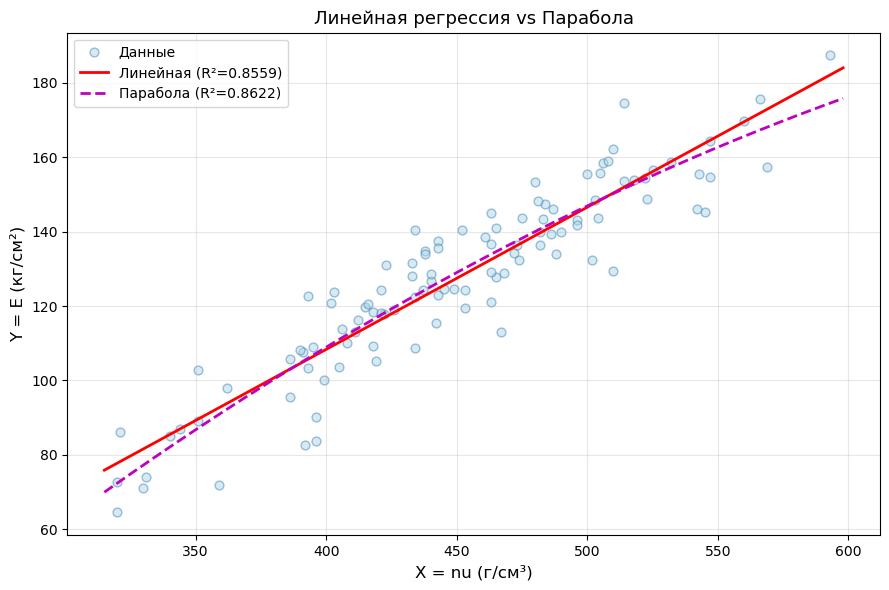

In [43]:
coeffs_par = np.polyfit(x, y, 2)  # [b2, b1, b0]
b2_par, b1_par, b0_par = coeffs_par
y_pred_par = np.polyval(coeffs_par, x)

R2_par = 1 - np.sum((y - y_pred_par)**2) / ss_tot
Se_par = np.sqrt(np.mean((y - y_pred_par)**2))
A_par  = np.mean(np.abs((y - y_pred_par) / y)) * 100

print('ПАРАБОЛА y = b0 + b1*x + b2*x²:')
print(f'  b2 = {b2_par:.6f}')
print(f'  b1 = {b1_par:.6f}')
print(f'  b0 = {b0_par:.6f}')
print(f'  Уравнение: ŷ = {b0_par:.4f} + {b1_par:.4f}x + {b2_par:.6f}x²')
print()
print(f'  R² = {R2_par:.6f}')
print(f'  Sε = {Se_par:.4f}')
print(f'  A  = {A_par:.4f}%')

x_line = np.linspace(x.min()-5, x.max()+5, 500)
y_line_lin = b0_yx + b1_yx * x_line  # linear from part 2
y_line_par = np.polyval(coeffs_par, x_line)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x, y, alpha=0.5, edgecolors='steelblue', facecolors='lightblue', s=40, label='Данные')
ax.plot(x_line, y_line_lin, 'r-',  linewidth=2, label=f'Линейная (R²={1-np.sum((y-(b0_yx+b1_yx*x))**2)/ss_tot:.4f})')
ax.plot(x_line, y_line_par, 'm--', linewidth=2, label=f'Парабола (R²={R2_par:.4f})')
ax.set_xlabel('X = nu (г/см³)', fontsize=12)
ax.set_ylabel('Y = E (кг/см²)', fontsize=12)
ax.set_title('Линейная регрессия vs Парабола', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('parabola.png', dpi=120, bbox_inches='tight')
plt.show()

**Выводы:**

Параболическая регрессия: $\hat{y} = b_0 + b_1 x + b_2 x^2$. Коэффициент $b_2 \approx 0$ по модулю очень мал, что свидетельствует о несущественном вкладе квадратичного члена. Коэффициент детерминации $R^2 = 0.8622$ лишь незначительно выше, чем у линейной модели ($R^2 = 0.8559$), прирост менее $0.7\%$. Это подтверждает, что зависимость между признаками **близка к линейной** и усложнение модели до параболы не даёт ощутимого выигрыша в качестве.

## 5. Корреляционная кривая (вариант 4): логарифмическая функция

$$\hat{y} = \beta_0 + \beta_1 \ln x$$

Линеаризация: $z = \ln x$, тогда задача сводится к линейной регрессии $y = \beta_0 + \beta_1 z$.

ЛОГАРИФМИЧЕСКАЯ y = b0 + b1*ln(x):
  b0 = -898.2467
  b1 = 168.1466
  Уравнение: ŷ = -898.2467 + 168.1466*ln(x)

  R² = 0.862157
  Sε = 9.1941
  A  = 6.0095%


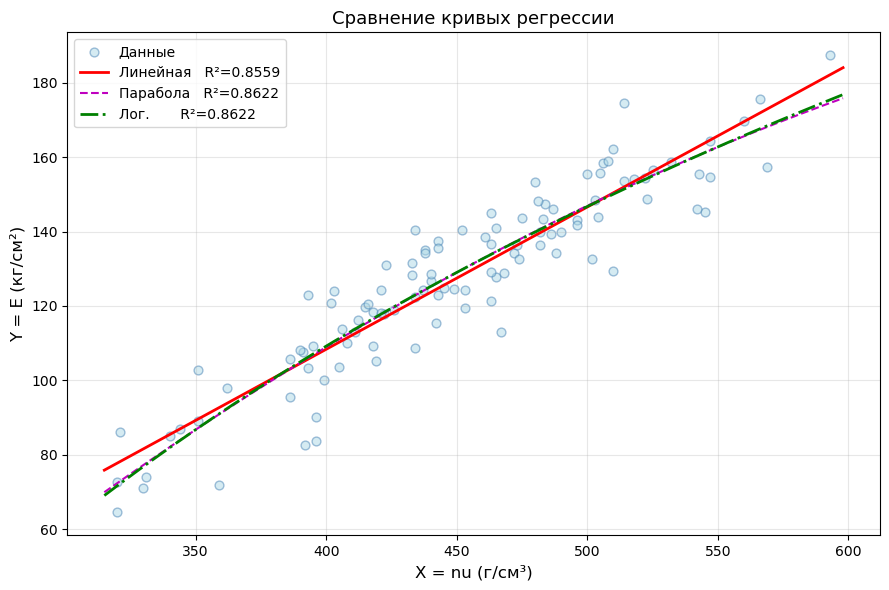

In [49]:
# y = b0 + b1*ln(x)
ln_x = np.log(x)
b1_log, b0_log, r_log, p_log, se_log = stats.linregress(ln_x, y)
y_pred_log = b0_log + b1_log * ln_x

R2_log = 1 - np.sum((y - y_pred_log)**2) / ss_tot
Se_log = np.sqrt(np.mean((y - y_pred_log)**2))
A_log  = np.mean(np.abs((y - y_pred_log) / y)) * 100

print('ЛОГАРИФМИЧЕСКАЯ y = b0 + b1*ln(x):')
print(f'  b0 = {b0_log:.4f}')
print(f'  b1 = {b1_log:.4f}')
print(f'  Уравнение: ŷ = {b0_log:.4f} + {b1_log:.4f}*ln(x)')
print()
print(f'  R² = {R2_log:.6f}')
print(f'  Sε = {Se_log:.4f}')
print(f'  A  = {A_log:.4f}%')

x_line = np.linspace(x.min()-5, x.max()+5, 500)
y_log_line = b0_log + b1_log * np.log(x_line)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x, y, alpha=0.5, edgecolors='steelblue', facecolors='lightblue', s=40, label='Данные')
ax.plot(x_line, y_line_lin, 'r-',   linewidth=2, label=f'Линейная   R²={1-np.sum((y-(b0_yx+b1_yx*x))**2)/ss_tot:.4f}')
ax.plot(x_line, y_line_par, 'm--',  linewidth=1.5, label=f'Парабола   R²={R2_par:.4f}')
ax.plot(x_line, y_log_line, 'g-.',  linewidth=2, label=f'Лог.       R²={R2_log:.4f}')
ax.set_xlabel('X = nu (г/см³)', fontsize=12)
ax.set_ylabel('Y = E (кг/см²)', fontsize=12)
ax.set_title('Сравнение кривых регрессии', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('log_curve.png', dpi=120, bbox_inches='tight')
plt.show()

**Выводы:**

Логарифмическая модель: $\hat{y} = -898.25 + 168.15 \cdot \ln x$. При $x \in [320, 593]$ функция $\ln x$ изменяется медленно и практически линейно, поэтому логарифмическая и линейная модели дают очень близкие результаты.

Коэффициент детерминации $R^2 = 0.8622$ — практически совпадает с параболой и незначительно превосходит линейную ($R^2 = 0.8559$). Средняя ошибка аппроксимации $A = 6.01\%$ — модель описывает данные с приемлемой точностью.

## 6. Дополнительное задание: показатели качества регрессии

Сравниваем три модели по трём критериям:
- $R^2$ — коэффициент детерминации (чем ближе к 1, тем лучше);
- $S_{\varepsilon}$ — среднеквадратическая ошибка (чем меньше, тем лучше);
- $A$ — средняя ошибка аппроксимации (приемлемо $A < 10\%$).

In [53]:
# Linear predictions
y_pred_lin = b0_yx + b1_yx * x
R2_lin = 1 - np.sum((y - y_pred_lin)**2) / ss_tot
Se_lin = np.sqrt(np.mean((y - y_pred_lin)**2))
A_lin  = np.mean(np.abs((y - y_pred_lin) / y)) * 100

models_quality = [
    ('Линейная:  y = b0 + b1*x',            R2_lin, Se_lin, A_lin),
    ('Парабола:  y = b0 + b1*x + b2*x²',   R2_par, Se_par, A_par),
    ('Лог.:      y = b0 + b1*ln(x)',         R2_log, Se_log, A_log),
]

print('СРАВНЕНИЕ МОДЕЛЕЙ:')
print(f'{'Модель':<40} {'R²':>8} {'Sε':>8} {'A, %':>8}')
print('-' * 66)
for name, R2, Se, A in models_quality:
    print(f'{name:<40} {R2:>8.6f} {Se:>8.4f} {A:>8.4f}')

best = max(models_quality, key=lambda t: t[1])
print()
print(f'Наилучшая модель по R²: {best[0].strip()}')

СРАВНЕНИЕ МОДЕЛЕЙ:
Модель                                         R²       Sε     A, %
------------------------------------------------------------------
Линейная:  y = b0 + b1*x                 0.855916   9.3999   6.1462
Парабола:  y = b0 + b1*x + b2*x²         0.862152   9.1943   6.0167
Лог.:      y = b0 + b1*ln(x)             0.862157   9.1941   6.0095

Наилучшая модель по R²: Лог.:      y = b0 + b1*ln(x)


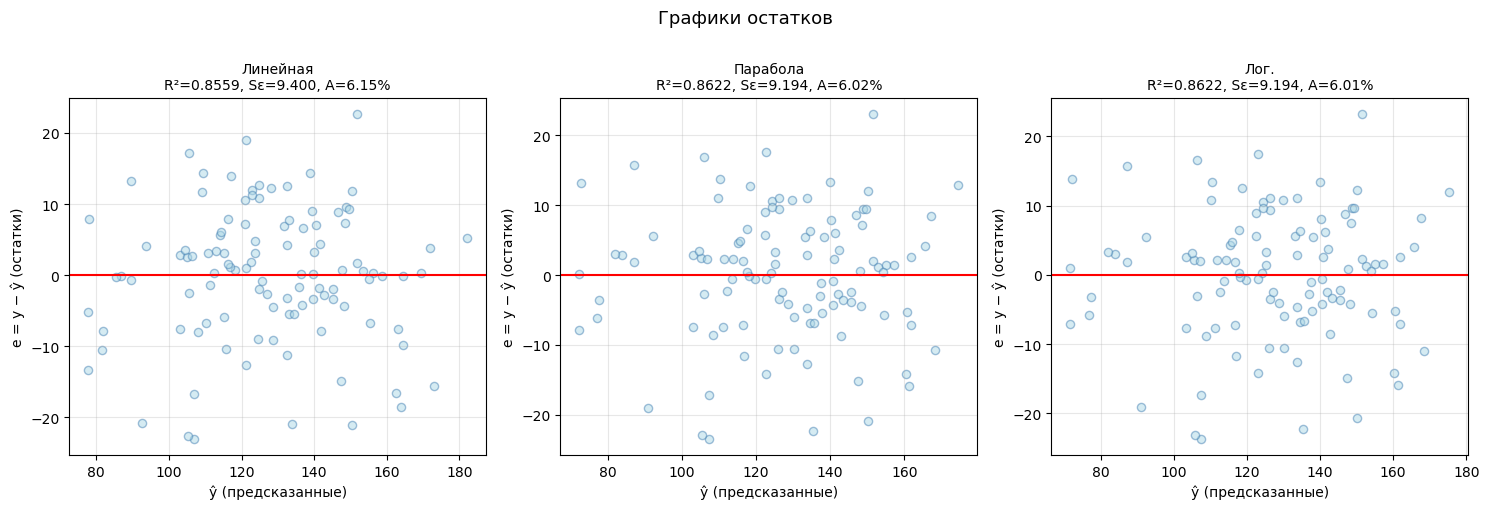

In [55]:
# Residuals plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, R2, Se, A), y_pred in zip(
    axes, models_quality,
    [y_pred_lin, y_pred_par, y_pred_log]
):
    residuals = y - y_pred
    ax.scatter(y_pred, residuals, alpha=0.5, edgecolors='steelblue',
               facecolors='lightblue', s=35)
    ax.axhline(0, color='red', linewidth=1.5)
    ax.set_xlabel('ŷ (предсказанные)', fontsize=10)
    ax.set_ylabel('e = y − ŷ (остатки)', fontsize=10)
    ax.set_title(f'{name.split(":")[0]}\nR²={R2:.4f}, Sε={Se:.3f}, A={A:.2f}%', fontsize=10)
    ax.grid(True, alpha=0.3)
plt.suptitle('Графики остатков', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('residuals.png', dpi=120, bbox_inches='tight')
plt.show()

## Выводы

В ходе практической работы проведён регрессионный анализ двумерной выборки ($n = 108$) по признакам **X = nu** (объёмный вес) и **Y = E** (модуль упругости).

**1. Диаграмма рассеяния** демонстрирует выраженную положительную линейную тенденцию с умеренным равномерным разбросом, что согласуется с $r = 0.9252$ (ПР №4).

**2. Прямые регрессии:**
- $\hat{y} = -44.5851 + 0.3823\,x$ — регрессия E на nu: рост объёмного веса на 1 г/см³ в среднем увеличивает модуль упругости на $0.38$ кг/см².
- $\hat{x} = 164.6381 + 2.2387\,y$ — регрессия nu на E. Обе прямые пересекаются в центре $(449.92;\; 127.43)$. Малый угол между прямыми подтверждает тесную линейную связь.

**3. Корреляционное отношение:**
$\eta_{y|x} = 0.9164 > |r| = 0.9087$ и $\eta_{x|y} = 0.9140 > |r| = 0.9087$.
Оба неравенства выполняются. Незначительное превышение $\eta$ над $|r|$ (менее $1\%$) свидетельствует о том, что связь **преимущественно линейная** — нелинейная составляющая пренебрежимо мала.

**4. Парабола** $\hat{y} = b_0 + b_1 x + b_2 x^2$: $R^2 = 0.8622$, $S_{\varepsilon} = 9.19$, $A = 6.02\%$. Прирост $R^2$ по сравнению с линейной моделью ($0.8559$) составляет лишь $0.63\%$, что подтверждает линейность зависимости.

**5. Логарифмическая модель** $\hat{y} = -898.25 + 168.15 \ln x$: $R^2 = 0.8622$, $S_{\varepsilon} = 9.19$, $A = 6.01\%$. В диапазоне данных $\ln x$ ведёт себя почти линейно, поэтому результат практически совпадает с параболой.

**6. Итог сравнения моделей:** все три модели (линейная, парабола, логарифмическая) дают близкие результаты качества ($R^2 \approx 0.86$, $A \approx 6\%$). Средняя ошибка аппроксимации $A < 10\%$ во всех случаях — модели пригодны для практического использования. С учётом принципа бережливости
предпочтительна **линейная** модель: она проста, интерпретируема и незначительно уступает более сложным.